# Parkinson's Disease Detection from Voice Biomarkers
## Demo Notebook

This notebook walks through the full pipeline for our PD classifier:
1. Loading the UCI Parkinsons dataset and inspecting class balance
2. Setting up subject-level CV splits (no data leakage)
3. Training the baseline MLP + Focal Loss on a single fold and plotting training curves
4. Running the full 5-fold baseline CV (reproducing Table 1)
5. Loss function ablation (reproducing Table 2)

For the complete set of experiments (architecture ablation, dropout sweep, all figures), run `python main.py` — takes ~2 min on CPU.

In [17]:
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from main import (
    load_data, get_features, prepare_fold, VoiceDataset,
    MLP, FocalLoss, train_model, evaluate, run_cv, summarize,
    plot_training_curves, DEVICE, SEED
)
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedGroupKFold
import torch.nn as nn

print(f"Device: {DEVICE}")

Device: cpu


## 1. Load Data

The dataset has 195 voice recordings from 32 subjects (23 PD, 8 healthy).
Each recording has 22 acoustic features — jitter, shimmer, HNR, and nonlinear
dynamical measures. The class split is roughly 75/25, which is why we use
Focal Loss instead of plain BCE.

In [18]:
df = load_data()
features = get_features(df)
print(f"Samples: {len(df)}, Features: {len(features)}, Subjects: {df['subject'].nunique()}")
print(f"Class distribution: {dict(df['status'].value_counts())}")
print(f"Positive rate: {df['status'].mean():.1%}")

Samples: 195, Features: 22, Subjects: 32
Class distribution: {1: 147, 0: 48}
Positive rate: 75.4%


## 2. Subject-Level Splits (No Data Leakage)

Each subject contributes ~6 recordings. If we do a naive random split, the same
person's voice ends up in both train and test — the model just memorizes
speaker identity rather than learning PD-specific patterns. StratifiedGroupKFold
ensures zero subject overlap between folds.

In [19]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(sgkf.split(df[features].values, df['status'].values, df['subject'].values))

for i, (tr, te) in enumerate(splits):
    tr_subj = set(df.iloc[tr]['subject'])
    te_subj = set(df.iloc[te]['subject'])
    overlap = tr_subj & te_subj
    print(f"Fold {i+1}: Train={len(tr)} samples ({len(tr_subj)} subjects), "
          f"Test={len(te)} samples ({len(te_subj)} subjects), "
          f"Subject overlap={len(overlap)}")

Fold 1: Train=158 samples (26 subjects), Test=37 samples (6 subjects), Subject overlap=0
Fold 2: Train=152 samples (25 subjects), Test=43 samples (7 subjects), Subject overlap=0
Fold 3: Train=158 samples (26 subjects), Test=37 samples (6 subjects), Subject overlap=0
Fold 4: Train=153 samples (25 subjects), Test=42 samples (7 subjects), Subject overlap=0
Fold 5: Train=159 samples (26 subjects), Test=36 samples (6 subjects), Subject overlap=0


## 3. Model Architecture

Quick look at the baseline model — MLP with hidden layers [64, 32], BatchNorm,
ReLU, and dropout 0.3. Pretty compact at under 4k parameters, which makes
sense given we only have 195 samples.

In [20]:
input_dim = len(features)
model = MLP(input_dim, [64, 32], dropout=0.3)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 3,777


## 4. Training Curves (Reproducing Figure 1)

We call `plot_training_curves` directly from `main.py` so the output is
identical to Figure 1 in the report — same fold, same random state, same
code path. The function trains on Fold 1 with the baseline config and
plots loss + F1/AUC over epochs. Passing `show=True` displays it inline
in the notebook (by default the function just saves to disk).

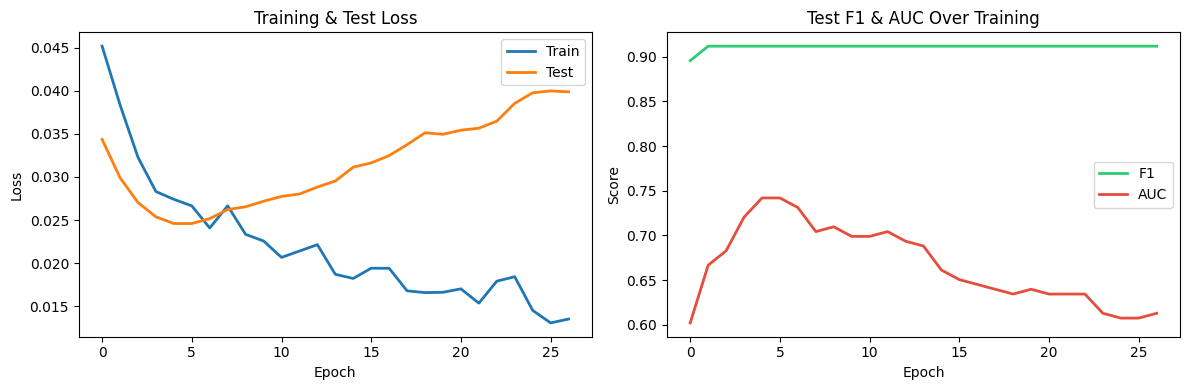

In [21]:
plot_training_curves(df, splits, input_dim, show=True)

## 5. Full 5-Fold Baseline (Reproducing Table 1)

Now we run all 5 folds to reproduce the baseline numbers from the report.
This takes about 20–30 seconds on CPU. The numbers should match Table 1
(small deviations are possible if running on GPU due to nondeterministic ops).

In [22]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model_fn = lambda: MLP(input_dim, [64, 32], dropout=0.3)
criterion = FocalLoss(alpha=0.25, gamma=2.0)
fold_metrics = run_cv(df, splits, model_fn, criterion, verbose=True)

print("\n" + "="*50)
baseline_summary = summarize(fold_metrics, "Baseline MLP [64, 32] + Focal Loss")

  Fold 1
    Epoch  25 | Train Loss: 0.0140 | Test F1: 0.923 AUC: 0.753
    Early stop at epoch 34
    → F1: 0.954  AUC: 0.844  MCC: 0.675
  Fold 2
    Epoch  25 | Train Loss: 0.0218 | Test F1: 0.830 AUC: 0.976
    Epoch  50 | Train Loss: 0.0134 | Test F1: 0.897 AUC: 0.927
    Epoch  75 | Train Loss: 0.0104 | Test F1: 0.900 AUC: 0.882
    Early stop at epoch 99
    → F1: 0.900  AUC: 0.887  MCC: 0.674
  Fold 3
    Epoch  25 | Train Loss: 0.0167 | Test F1: 0.873 AUC: 0.820
    Early stop at epoch 27
    → F1: 0.893  AUC: 0.793  MCC: 0.635
  Fold 4
    Epoch  25 | Train Loss: 0.0133 | Test F1: 0.844 AUC: 0.667
    Early stop at epoch 47
    → F1: 0.844  AUC: 0.683  MCC: 0.364
  Fold 5
    Epoch  25 | Train Loss: 0.0154 | Test F1: 0.875 AUC: 0.622
    Early stop at epoch 44
    → F1: 0.875  AUC: 0.583  MCC: -0.108


  Baseline MLP [64, 32] + Focal Loss:
    accuracy    : 0.831 ± 0.057
    f1          : 0.893 ± 0.036
    auc         : 0.758 ± 0.111
    mcc         : 0.448 ± 0.301


## 6. Loss Function Ablation (Reproducing Table 2)

We compare five loss functions to see how much the training objective matters.
The differences are pretty modest on this dataset — all get F1 in the
0.88–0.92 range. The bigger story is that Weighted BCE actually hurts, probably
because it over-corrects for the imbalance on such a small dataset.

In [23]:
loss_configs = {
    "BCE": nn.BCEWithLogitsLoss(),
    "Weighted BCE": nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([48.0 / 147.0]).to(DEVICE)
    ),
    "Focal \u03b3=1": FocalLoss(0.25, 1.0),
    "Focal \u03b3=2": FocalLoss(0.25, 2.0),
    "Focal \u03b3=3": FocalLoss(0.25, 3.0),
}

loss_results = {}
for name, crit in loss_configs.items():
    print(f"\n--- {name} ---")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model_fn = lambda: MLP(input_dim, [64, 32], dropout=0.3)
    fm = run_cv(df, splits, model_fn, crit, verbose=False)
    loss_results[name] = summarize(fm, name)


--- BCE ---

  BCE:
    accuracy    : 0.845 ± 0.063
    f1          : 0.901 ± 0.034
    auc         : 0.780 ± 0.194
    mcc         : 0.502 ± 0.335

--- Weighted BCE ---

  Weighted BCE:
    accuracy    : 0.799 ± 0.059
    f1          : 0.860 ± 0.044
    auc         : 0.799 ± 0.131
    mcc         : 0.454 ± 0.251

--- Focal γ=1 ---

  Focal γ=1:
    accuracy    : 0.829 ± 0.054
    f1          : 0.891 ± 0.037
    auc         : 0.805 ± 0.117
    mcc         : 0.432 ± 0.287

--- Focal γ=2 ---

  Focal γ=2:
    accuracy    : 0.831 ± 0.057
    f1          : 0.893 ± 0.036
    auc         : 0.758 ± 0.111
    mcc         : 0.448 ± 0.301

--- Focal γ=3 ---

  Focal γ=3:
    accuracy    : 0.859 ± 0.066
    f1          : 0.911 ± 0.042
    auc         : 0.808 ± 0.149
    mcc         : 0.521 ± 0.336


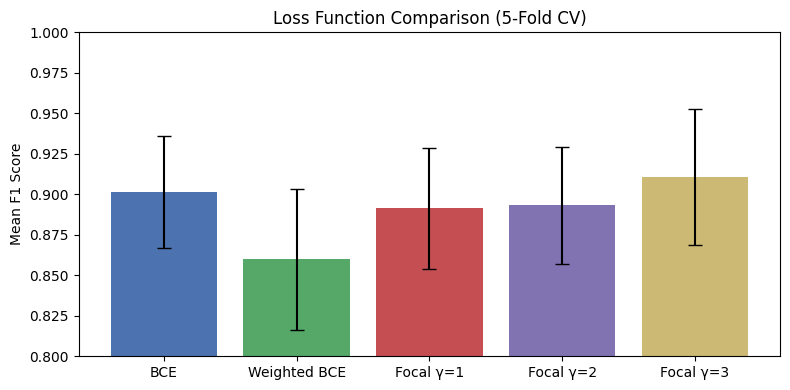

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(loss_results.keys())
f1s = [loss_results[n]["f1"][0] for n in names]
stds = [loss_results[n]["f1"][1] for n in names]
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]
ax.bar(names, f1s, yerr=stds, capsize=5, color=colors)
ax.set_ylabel("Mean F1 Score")
ax.set_title("Loss Function Comparison (5-Fold CV)")
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## 7. Additional Experiments

The architecture ablation and dropout sweep take a few more minutes to run.
You can reproduce those by running:

```bash
python main.py
```

This saves all results to `results/results.json` and figures to `results/figures/`.
The report discusses those results in Sections 7.3 and 7.4.